In [1]:
import pandas as pd

In [2]:
import os

print(os.getcwd())
print(os.listdir())

/Users/jordonchau
['.config', 'Music', 'Untitled1.ipynb', 'html ', '.DS_Store', '.CFUserTextEncoding', '.xonshrc', 'Untitled.ipynb', '.zshrc', 'english_files.txt', 'Pictures', '.zprofile', '.nvm', 'Personal-Website', '.zsh_history', '.ipython', 'Desktop', 'Library', 'nexus-clean', '.matplotlib', '.lesshst', 'nexus 2', 'nexus.zip', '.cups', 'korean_files.txt', 'nexus', 'Public', 'W1 Class overview and Numerical Python basics (2).ipynb', '.tcshrc', '.anaconda', 'Movies', 'Applications', '.Trash', '.ipynb_checkpoints', '.jupyter', '.zcompdump', '.npm', 'housing_affordability_analysis.csv', 'Documents', 'housing_analysis.ipynb', '.vscode', '.bash_profile', 'Downloads', '.continuum', '.gitconfig', '.viminfo', '.zsh_sessions', '.conda']


In [3]:
rent_df = pd.read_csv("/Users/jordonchau/Documents/housing_project/rent_data_clean.csv")

In [4]:
income_df = pd.read_csv("/Users/jordonchau/Documents/housing_project/income_data_clean.csv")

In [5]:
print(rent_df.head())
print("\n")
print(income_df.head())

   ZIPCode RegionType StateName State      City  \
0    77494        zip        TX    TX      Katy   
1     8701        zip        NJ    NJ  Lakewood   
2    77449        zip        TX    TX      Katy   
3    11368        zip        NY    NY  New York   
4    77084        zip        TX    TX   Houston   

                                   Metro        CountyName  Median Rent  
0   Houston-The Woodlands-Sugar Land, TX  Fort Bend County  1730.750613  
1  New York-Newark-Jersey City, NY-NJ-PA      Ocean County  2124.000000  
2   Houston-The Woodlands-Sugar Land, TX     Harris County  1810.841402  
3  New York-Newark-Jersey City, NY-NJ-PA     Queens County  2677.777778  
4   Houston-The Woodlands-Sugar Land, TX     Harris County  1579.208691  


   ZIPCode MedianIncome  ZipCode
0     7001       101670     7001
1     7002        83887     7002
2     7003       103663     7003
3     7004       115980     7004
4     7005       132629     7005


In [6]:
rent_df = rent_df[rent_df['State'].isin(['NY', 'NJ'])]

In [7]:
print(rent_df['State'].value_counts())

State
NY    421
NJ    271
Name: count, dtype: int64


In [8]:
print(income_df.columns.tolist())

['ZIPCode', 'MedianIncome', 'ZipCode']


In [9]:
income_df = income_df[['ZIPCode', 'MedianIncome']]

In [10]:
rent_df['ZIPCode'] = rent_df['ZIPCode'].astype(str).str.zfill(5)
income_df['ZIPCode'] = income_df['ZIPCode'].astype(str).str.zfill(5)

In [11]:
merged_df = pd.merge(
    rent_df,
    income_df,
    on='ZIPCode',
    how='inner'
)

print(merged_df.head())
print(merged_df.shape)

  ZIPCode RegionType StateName State      City  \
0   08701        zip        NJ    NJ  Lakewood   
1   11368        zip        NY    NY  New York   
2   11385        zip        NY    NY  New York   
3   11208        zip        NY    NY  New York   
4   11236        zip        NY    NY  New York   

                                   Metro     CountyName  Median Rent  \
0  New York-Newark-Jersey City, NY-NJ-PA   Ocean County  2124.000000   
1  New York-Newark-Jersey City, NY-NJ-PA  Queens County  2677.777778   
2  New York-Newark-Jersey City, NY-NJ-PA  Queens County  3339.743772   
3  New York-Newark-Jersey City, NY-NJ-PA   Kings County  3227.301587   
4  New York-Newark-Jersey City, NY-NJ-PA   Kings County  3132.722222   

  MedianIncome  
0        64959  
1        72270  
2        88838  
3        62077  
4        81464  
(692, 9)


In [12]:
print(income_df.columns.tolist())
print(merged_df.shape)

['ZIPCode', 'MedianIncome']
(692, 9)


In [13]:
merged_df['MedianIncome'] = (
    merged_df['MedianIncome']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

merged_df['MedianIncome'] = pd.to_numeric(
    merged_df['MedianIncome'],
    errors='coerce'
)

merged_df = merged_df.dropna(subset=['MedianIncome'])

In [14]:
merged_df['AnnualRent'] = merged_df['Median Rent'] * 12

In [15]:
#percentage of a households annual income that would go toward rent

merged_df['RentBurdenPct'] = (
        merged_df['AnnualRent'] /
        merged_df['MedianIncome']
) * 100

print(merged_df[['ZIPCode', 'City', 'Median Rent', 'MedianIncome', 'RentBurdenPct']].head())

  ZIPCode      City  Median Rent  MedianIncome  RentBurdenPct
0   08701  Lakewood  2124.000000       64959.0      39.237057
1   11368  New York  2677.777778       72270.0      44.462894
2   11385  New York  3339.743772       88838.0      45.112368
3   11208  New York  3227.301587       62077.0      62.386422
4   11236  New York  3132.722222       81464.0      46.146355


In [16]:
# lowest rent burden = most affordable
merged_df.sort_values('RentBurdenPct')[
    ['ZIPCode', 'City', 'CountyName', 'Median Rent', 'MedianIncome', 'RentBurdenPct']
].head(10)

,ZIPCode,City,CountyName,Median Rent,MedianIncome,RentBurdenPct
333,07869,Randolph,Morris County,2073.333333,169497.0,14.678726
255,12309,Schenectady,Schenectady County,1593.888889,125274.0,15.267866
259,07090,Westfield,Union County,3043.531746,232629.0,15.699840
490,08033,Haddonfield,Camden County,2005.388889,151181.0,15.917785
545,08824,Kendall Park,Middlesex County,2325.250000,174776.0,15.965007
542,07836,Flanders,Morris County,2036.500000,151915.0,16.086627
417,14468,Hilton,Monroe County,1328.333333,98693.0,16.151095
558,14586,West Henrietta,Monroe County,1695.000000,124457.0,16.342994
385,08057,Moorestown Township,Burlington County,2173.333333,158770.0,16.426277
516,13215,Syracuse,Onondaga County,1560.133333,113864.0,16.442071


In [17]:
# highest rent burden = least affordable
merged_df.sort_values('RentBurdenPct', ascending=False)[
    ['ZIPCode', 'City', 'CountyName', 'Median Rent', 'MedianIncome', 'RentBurdenPct']
].head(10)

,ZIPCode,City,CountyName,Median Rent,MedianIncome,RentBurdenPct
683,11976,Water Mill,Suffolk County,105972.16670,180250.0,705.501248
656,11963,Sag Harbor,Suffolk County,45152.76667,127746.0,424.148858
421,11937,East Hampton,Suffolk County,38503.58036,129883.0,355.737829
585,11968,Southampton,Suffolk County,40522.26740,156219.0,311.272770
672,11954,Montauk,Suffolk County,36861.11111,142961.0,309.408393
678,11978,Westhampton Beach,Suffolk County,27715.27778,125179.0,265.686204
680,11977,Westhampton,Suffolk County,26500.00000,151375.0,210.074319
517,11946,Hampton Bays,Suffolk County,16498.92222,133918.0,147.842013
190,10454,New York,Bronx County,2924.70000,24086.0,145.712862
662,08402,Margate City,Atlantic County,13083.33333,121800.0,128.899836


In [18]:
merged_df.to_csv("housing_affordability_analysis.csv", index=False)

In [19]:
merged_df['RentBurdenPct'] = merged_df['RentBurdenPct'].round(2)
merged_df['Median Rent'] = merged_df['Median Rent'].round(0)

In [20]:
# Most Affordable Zip Codes

most_affordable = merged_df.sort_values('RentBurdenPct')

print(most_affordable[
    ['ZIPCode', 'City', 'CountyName', 'Median Rent', 'MedianIncome', 'RentBurdenPct']
].head(10))

    ZIPCode                 City          CountyName  Median Rent  \
333   07869             Randolph       Morris County       2073.0   
255   12309          Schenectady  Schenectady County       1594.0   
259   07090            Westfield        Union County       3044.0   
490   08033          Haddonfield       Camden County       2005.0   
545   08824         Kendall Park    Middlesex County       2325.0   
542   07836             Flanders       Morris County       2036.0   
417   14468               Hilton       Monroe County       1328.0   
558   14586       West Henrietta       Monroe County       1695.0   
385   08057  Moorestown Township   Burlington County       2173.0   
516   13215             Syracuse     Onondaga County       1560.0   

     MedianIncome  RentBurdenPct  
333      169497.0          14.68  
255      125274.0          15.27  
259      232629.0          15.70  
490      151181.0          15.92  
545      174776.0          15.97  
542      151915.0          16.

In [21]:
# Least Affordable Zip Codes

least_affordable = merged_df.sort_values(
    'RentBurdenPct',
    ascending=False
)

print(least_affordable[
    ['ZIPCode', 'City', 'CountyName', 'Median Rent', 'MedianIncome', 'RentBurdenPct']
].head(10))

    ZIPCode               City       CountyName  Median Rent  MedianIncome  \
683   11976         Water Mill   Suffolk County     105972.0      180250.0   
656   11963         Sag Harbor   Suffolk County      45153.0      127746.0   
421   11937       East Hampton   Suffolk County      38504.0      129883.0   
585   11968        Southampton   Suffolk County      40522.0      156219.0   
672   11954            Montauk   Suffolk County      36861.0      142961.0   
678   11978  Westhampton Beach   Suffolk County      27715.0      125179.0   
680   11977        Westhampton   Suffolk County      26500.0      151375.0   
517   11946       Hampton Bays   Suffolk County      16499.0      133918.0   
190   10454           New York     Bronx County       2925.0       24086.0   
662   08402       Margate City  Atlantic County      13083.0      121800.0   

     RentBurdenPct  
683         705.50  
656         424.15  
421         355.74  
585         311.27  
672         309.41  
678         265

In [22]:
!pip install matplotlib

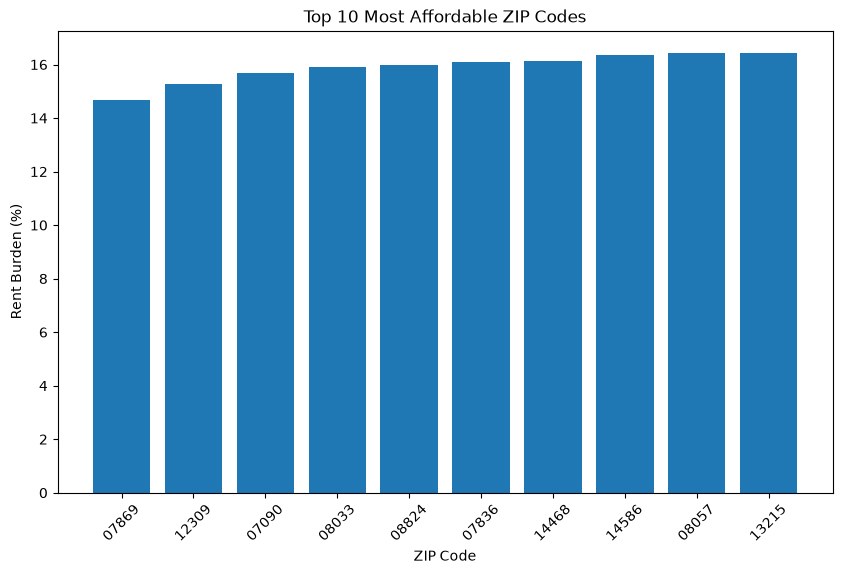

In [23]:
import matplotlib.pyplot as plt

top10 = merged_df.nsmallest(10, 'RentBurdenPct')

plt.figure(figsize=(10,6))
plt.bar(top10['ZIPCode'], top10['RentBurdenPct'])
plt.title('Top 10 Most Affordable ZIP Codes')
plt.xlabel('ZIP Code')
plt.ylabel('Rent Burden (%)')
plt.xticks(rotation=45)
plt.show()

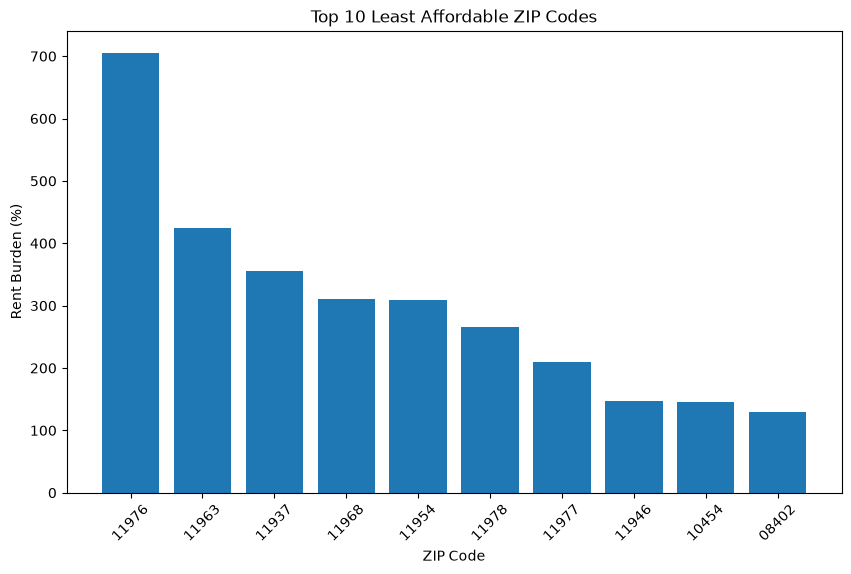

In [24]:
top10 = merged_df.nlargest(10, 'RentBurdenPct')

plt.figure(figsize=(10,6))
plt.bar(top10['ZIPCode'], top10['RentBurdenPct'])
plt.title('Top 10 Least Affordable ZIP Codes')
plt.xlabel('ZIP Code')
plt.ylabel('Rent Burden (%)')
plt.xticks(rotation=45)
plt.show()

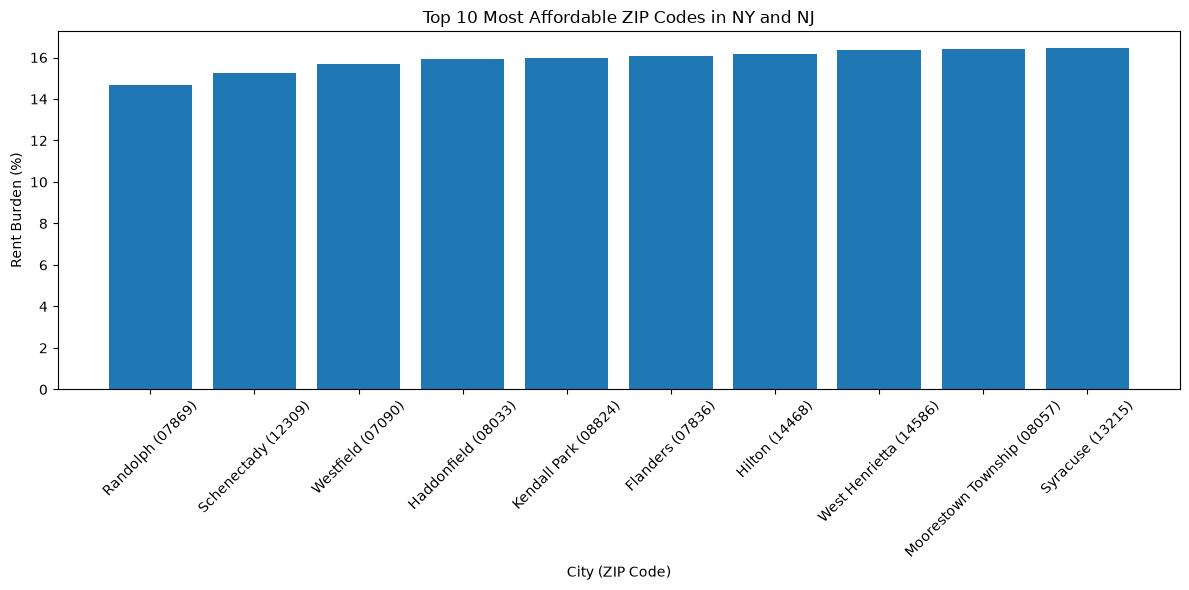

In [25]:
top10 = merged_df.nsmallest(10, 'RentBurdenPct')

plt.figure(figsize=(12,6))
plt.bar(top10['City'] + ' (' + top10['ZIPCode'] + ')',
        top10['RentBurdenPct'])

plt.title('Top 10 Most Affordable ZIP Codes in NY and NJ')
plt.xlabel('City (ZIP Code)')
plt.ylabel('Rent Burden (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

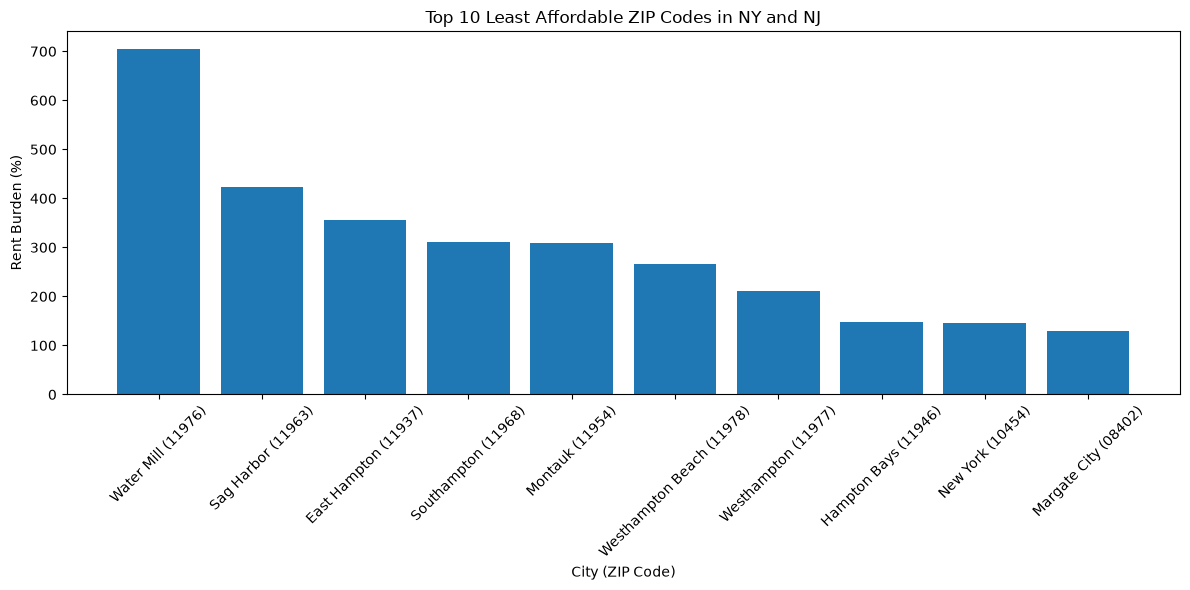

In [26]:
top10 = merged_df.nlargest(10, 'RentBurdenPct')

plt.figure(figsize=(12,6))
plt.bar(top10['City'] + ' (' + top10['ZIPCode'] + ')',
        top10['RentBurdenPct'])

plt.title('Top 10 Least Affordable ZIP Codes in NY and NJ')
plt.xlabel('City (ZIP Code)')
plt.ylabel('Rent Burden (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

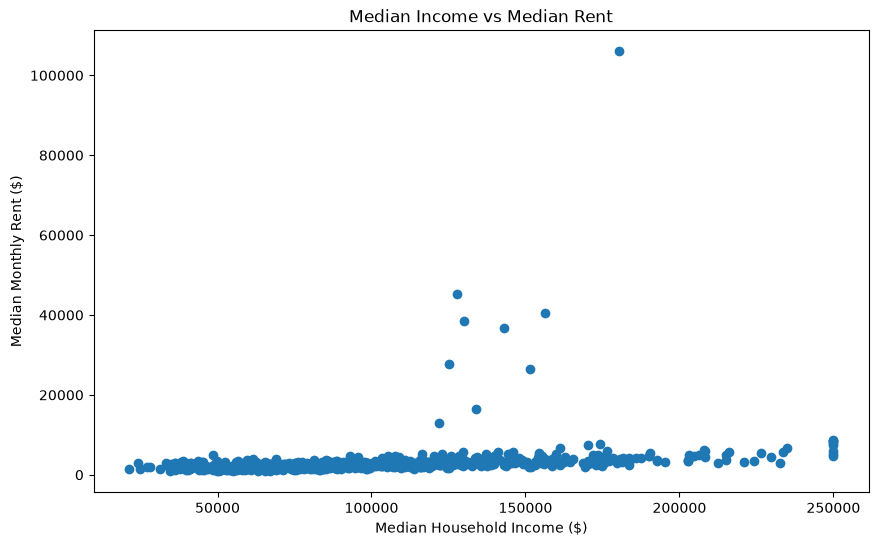

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged_df['MedianIncome'],
    merged_df['Median Rent']
)

plt.title('Median Income vs Median Rent')
plt.xlabel('Median Household Income ($)')
plt.ylabel('Median Monthly Rent ($)')
plt.show()

In [28]:
least_affordable = merged_df.nlargest(10, 'RentBurdenPct')

print(
    least_affordable[
        ['ZIPCode',
         'City',
         'Median Rent',
         'MedianIncome',
         'RentBurdenPct']
    ]
)

    ZIPCode               City  Median Rent  MedianIncome  RentBurdenPct
683   11976         Water Mill     105972.0      180250.0         705.50
656   11963         Sag Harbor      45153.0      127746.0         424.15
421   11937       East Hampton      38504.0      129883.0         355.74
585   11968        Southampton      40522.0      156219.0         311.27
672   11954            Montauk      36861.0      142961.0         309.41
678   11978  Westhampton Beach      27715.0      125179.0         265.69
680   11977        Westhampton      26500.0      151375.0         210.07
517   11946       Hampton Bays      16499.0      133918.0         147.84
190   10454           New York       2925.0       24086.0         145.71
662   08402       Margate City      13083.0      121800.0         128.90


In [29]:
merged_df.groupby('City')['RentBurdenPct'].mean().sort_values(ascending=False)

City
Water Mill      705.50
Sag Harbor      424.15
East Hampton    355.74
Southampton     311.27
Montauk         309.41
                 ...  
Haddonfield      15.92
Westfield        15.70
Randolph         14.68
Riverdale          NaN
Setauket           NaN
Name: RentBurdenPct, Length: 409, dtype: float64

In [30]:
import sqlite3

In [32]:
# Create SQLite Database
conn = sqlite3.connect("housing_project.db")

merged_df.to_sql(
    "housing_data",
    conn,
    if_exists="replace",
    index=False
)

691

In [33]:
query = """
SELECT ZIPCode,
       City,
       State,
       "Median Rent",
       MedianIncome,
       RentBurdenPct
FROM housing_data
ORDER BY RentBurdenPct ASC
LIMIT 10;
"""

In [34]:
pd.read_sql(query, conn)

,ZIPCode,City,State,Median Rent,MedianIncome,RentBurdenPct
0,11733,Setauket,NY,NaN,173281.0,NaN
1,07457,Riverdale,NJ,NaN,102950.0,NaN
2,07869,Randolph,NJ,2073.0,169497.0,14.68
3,12309,Schenectady,NY,1594.0,125274.0,15.27
4,07090,Westfield,NJ,3044.0,232629.0,15.70
5,08033,Haddonfield,NJ,2005.0,151181.0,15.92
6,08824,Kendall Park,NJ,2325.0,174776.0,15.97
7,07836,Flanders,NJ,2036.0,151915.0,16.09
8,14468,Hilton,NY,1328.0,98693.0,16.15
9,14586,West Henrietta,NY,1695.0,124457.0,16.34


In [35]:
query = """
SELECT CountyName,
       ROUND(AVG(RentBurdenPct), 2) AS AvgRentBurden
FROM housing_data
GROUP BY CountyName
ORDER BY AvgRentBurden DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,CountyName,AvgRentBurden
0,Suffolk County,109.39
1,Bronx County,74.15
2,Atlantic County,50.46
3,New York County,49.47
4,Kings County,49.22
5,Queens County,40.17
6,Essex County,38.22
7,Passaic County,37.42
8,Ocean County,36.86
9,Columbia County,35.12


In [38]:
merged_df.to_csv(
    "/Users/jordonchau/Documents/housing_project/housing_affordability_analysis.csv",
    index=False
)